# Using LSTM

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import re 

In [2]:
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import Dropout, Bidirectional

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [4]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alwin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alwin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("train.csv")

In [6]:
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [7]:
df.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

In [8]:
df.shape

(20800, 5)

In [9]:
df = df.dropna()

In [10]:
df.shape

(18285, 5)

In [11]:
df.isnull().sum()

id        0
title     0
author    0
text      0
label     0
dtype: int64

In [12]:
X = df.drop('label',axis=1)

In [13]:
y = df['label']

In [14]:
y.value_counts()

0    10361
1     7924
Name: label, dtype: int64

In [15]:
voc_size = 5000 # Vocabulary Size is for no. of unique words in corpus

## Text preprocessing

In [16]:
messages=X.copy() 

In [17]:
messages['title'][1]

'FLYNN: Hillary Clinton, Big Woman on Campus - Breitbart'

In [18]:
stemmer = PorterStemmer()
corpus = []

title_iterator = iter(messages['title'])

for title in title_iterator:
    review = re.sub('[^a-zA-Z]', ' ', title) # removing special char other than a,A to z,Z
    review = review.lower()
    review = review.split() # sent tokenization
    
    review = [stemmer.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)  

In [19]:
print('***prev sent***')
print(messages['title'][1])
print('***stem sent***')
print(corpus[1])

***prev sent***
FLYNN: Hillary Clinton, Big Woman on Campus - Breitbart
***stem sent***
flynn hillari clinton big woman campu breitbart


In [20]:
onehot_repr=[one_hot(words,voc_size)for words in corpus] 
print(onehot_repr[0])
print(onehot_repr[1])

[526, 701, 4652, 4280, 1352, 1457, 3587, 3654, 1586, 48]
[4683, 2047, 3277, 3549, 1016, 2825, 2338]


In [21]:
messages=X.copy() 

In [22]:
# add padding to make it same size
# Lets consider one Maximum Sentence Length
sent_length=20
embedded_docs=pad_sequences(onehot_repr,padding='post',maxlen=sent_length)

In [23]:
print(embedded_docs)

[[ 526  701 4652 ...    0    0    0]
 [4683 2047 3277 ...    0    0    0]
 [1486  244 1248 ...    0    0    0]
 ...
 [2774 2401 4809 ...    0    0    0]
 [1486 2765  592 ...    0    0    0]
 [3930  720 1711 ...    0    0    0]]


In [24]:
embedding_vector_features = 100 
model = Sequential()
model.add(Embedding(voc_size, embedding_vector_features))
model.add(Bidirectional(LSTM(128, return_sequences=True)))  
model.add(Dropout(0.3)) 
model.add(LSTM(128))  
model.add(Dropout(0.3)) 
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 100)         500000    
                                                                 
 bidirectional (Bidirection  (None, None, 256)         234496    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, None, 256)         0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                        

In [25]:
X_final = np.array(embedded_docs)
y_final=np.array(y)

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.33, random_state=42)

In [27]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
192/192 [==============================] - 19s 77ms/step - loss: 0.2737 - accuracy: 0.8725 - val_loss: 0.2036 - val_accuracy: 0.9176
Epoch 2/10
192/192 [==============================] - 14s 72ms/step - loss: 0.1232 - accuracy: 0.9526 - val_loss: 0.2093 - val_accuracy: 0.9183
Epoch 3/10
192/192 [==============================] - 14s 71ms/step - loss: 0.0792 - accuracy: 0.9726 - val_loss: 0.2620 - val_accuracy: 0.9152
Epoch 4/10
192/192 [==============================] - 14s 75ms/step - loss: 0.0582 - accuracy: 0.9808 - val_loss: 0.3077 - val_accuracy: 0.9094
Epoch 5/10
192/192 [==============================] - 14s 73ms/step - loss: 0.0415 - accuracy: 0.9877 - val_loss: 0.2993 - val_accuracy: 0.9117
Epoch 6/10
192/192 [==============================] - 14s 74ms/step - loss: 0.0280 - accuracy: 0.9909 - val_loss: 0.3195 - val_accuracy: 0.9186
Epoch 7/10
192/192 [==============================] - 14s 73ms/step - loss: 0.0269 - accuracy: 0.9913 - val_loss: 0.4353 - val_accuracy:

In [28]:
y_pred=model.predict(X_test)

189/189 [==============================] - 3s 10ms/step


In [29]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 100)         500000    
                                                                 
 bidirectional (Bidirection  (None, None, 256)         234496    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, None, 256)         0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                        

In [30]:
y_pred=np.where(y_pred > 0.5, 1,0)

In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[3122,  297],
       [ 235, 2381]], dtype=int64)

In [32]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.911847555923778

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3419
           1       0.89      0.91      0.90      2616

    accuracy                           0.91      6035
   macro avg       0.91      0.91      0.91      6035
weighted avg       0.91      0.91      0.91      6035



In [34]:
#Accuraacy and loss flow

Epoch 1/10
383/383 [==============================] - 16s 42ms/step - loss: 0.0287 - accuracy: 0.9906 - val_loss: 0.3964 - val_accuracy: 0.9056
Epoch 2/10
383/383 [==============================] - 17s 43ms/step - loss: 0.0291 - accuracy: 0.9903 - val_loss: 0.4598 - val_accuracy: 0.9095
Epoch 3/10
383/383 [==============================] - 17s 44ms/step - loss: 0.0141 - accuracy: 0.9953 - val_loss: 0.4314 - val_accuracy: 0.9047
Epoch 4/10
383/383 [==============================] - 16s 42ms/step - loss: 0.0076 - accuracy: 0.9968 - val_loss: 0.5751 - val_accuracy: 0.9054
Epoch 5/10
383/383 [==============================] - 17s 43ms/step - loss: 0.0067 - accuracy: 0.9979 - val_loss: 0.6534 - val_accuracy: 0.9092
Epoch 6/10
383/383 [==============================] - 17s 45ms/step - loss: 0.0084 - accuracy: 0.9974 - val_loss: 0.6225 - val_accuracy: 0.9120
Epoch 7/10
383/383 [==============================] - 17s 45ms/step - loss: 0.0073 - accuracy: 0.9975 - val_loss: 0.5598 - val_accuracy:

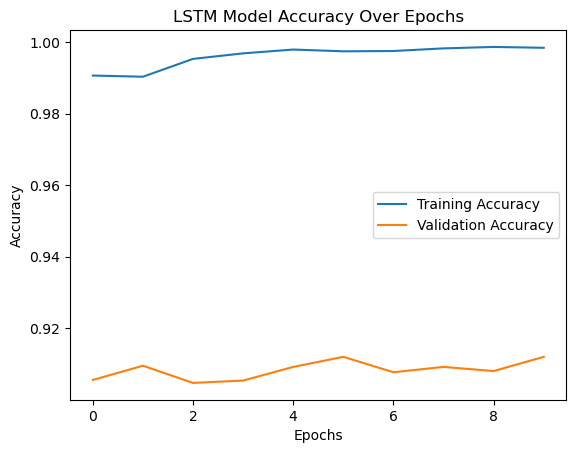

In [35]:
import matplotlib.pyplot as plt
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM Model Accuracy Over Epochs')
plt.legend()
plt.show()

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Label the data
fake["label"] = 0
true["label"] = 1

# Combine datasets
data = pd.concat([fake, true], axis=0)

# Shuffle data
data = data.sample(frac=1).reset_index(drop=True)

# Split data
X = data['text']  # or 'title' or 'combined' fields
y = data['label']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_vec = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

In [37]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9962138084632517
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4653
           1       1.00      0.99      1.00      4327

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [38]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9839643652561247
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4653
           1       0.98      0.98      0.98      4327

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [39]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9388641425389755
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4653
           1       0.94      0.93      0.94      4327

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [41]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9910913140311804
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4653
           1       0.99      0.99      0.99      4327

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



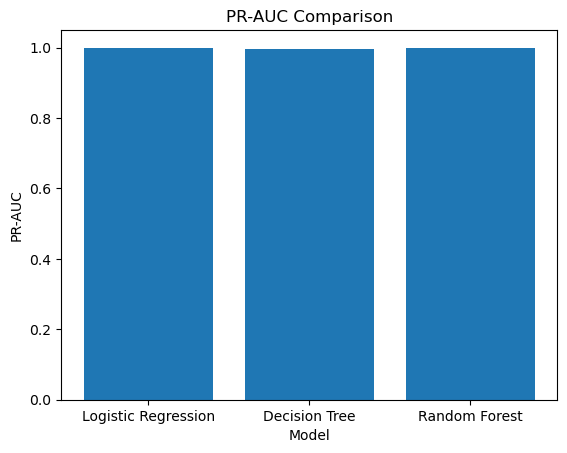

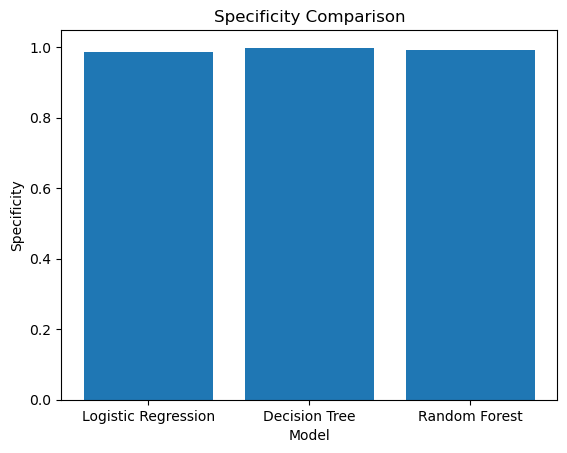

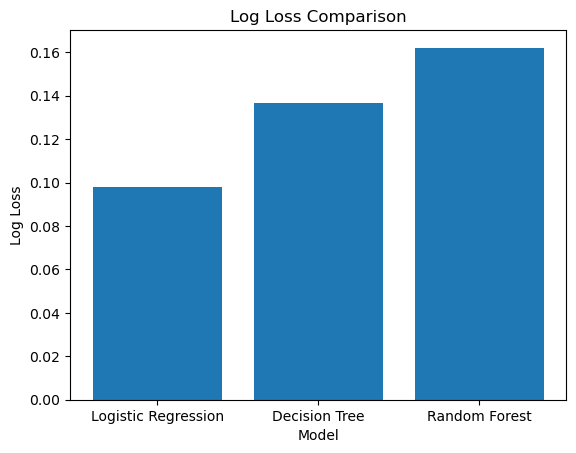

In [42]:
from sklearn.metrics import log_loss, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

models = {
    'Logistic Regression': (lr_model, y_pred_lr),
    'Decision Tree': (dt_model, y_pred_dt),
    'Random Forest': (rf_model, y_pred_rf)
}

metrics = {'Model': [], 'PR-AUC': [], 'Specificity': [], 'Log Loss': []}
for name, (model, y_pred) in models.items():
    probas = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, probas)
    ll = log_loss(y_test, probas)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)
    metrics['Model'].append(name)
    metrics['PR-AUC'].append(pr_auc)
    metrics['Specificity'].append(spec)
    metrics['Log Loss'].append(ll)

df_metrics = pd.DataFrame(metrics)

# PR-AUC Comparison
plt.figure()
plt.bar(df_metrics['Model'], df_metrics['PR-AUC'])
plt.title('PR-AUC Comparison')
plt.xlabel('Model')
plt.ylabel('PR-AUC')
plt.show()

# Specificity Comparison
plt.figure()
plt.bar(df_metrics['Model'], df_metrics['Specificity'])
plt.title('Specificity Comparison')
plt.xlabel('Model')
plt.ylabel('Specificity')
plt.show()

# Log Loss Comparison
plt.figure()
plt.bar(df_metrics['Model'], df_metrics['Log Loss'])
plt.title('Log Loss Comparison')
plt.xlabel('Model')
plt.ylabel('Log Loss')
plt.show()


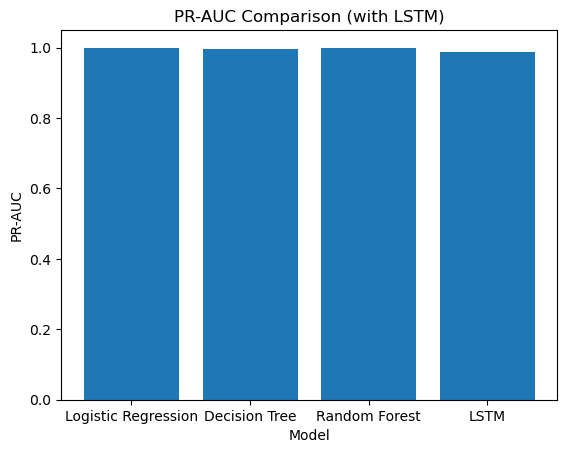

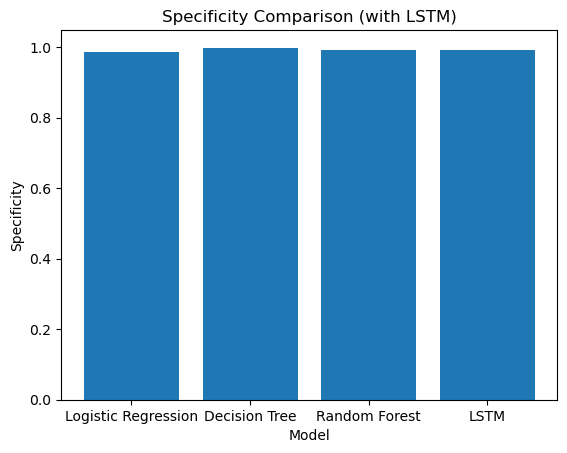

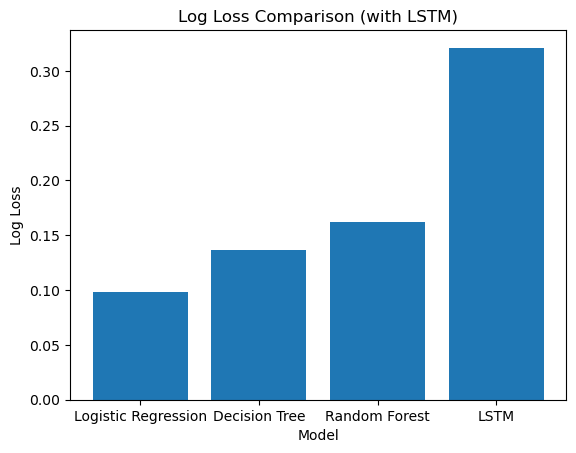

In [43]:
# LSTM Predictions
lstm_pred_probs = model.predict(X_test).flatten()
lstm_preds = (lstm_pred_probs > 0.5).astype(int)

# LSTM Metrics
pr_auc_lstm = average_precision_score(y_test, lstm_pred_probs)
ll_lstm = log_loss(y_test, lstm_pred_probs)
tn, fp, fn, tp = confusion_matrix(y_test, lstm_preds).ravel()
spec_lstm = tn / (tn + fp)

# Append to DataFrame
df_metrics.loc[len(df_metrics)] = ['LSTM', pr_auc_lstm, spec_lstm, ll_lstm]

# Updated plots with LSTM included
plt.figure()
plt.bar(df_metrics['Model'], df_metrics['PR-AUC'])
plt.title('PR-AUC Comparison (with LSTM)')
plt.xlabel('Model')
plt.ylabel('PR-AUC')
plt.show()

plt.figure()
plt.bar(df_metrics['Model'], df_metrics['Specificity'])
plt.title('Specificity Comparison (with LSTM)')
plt.xlabel('Model')
plt.ylabel('Specificity')
plt.show()

plt.figure()
plt.bar(df_metrics['Model'], df_metrics['Log Loss'])
plt.title('Log Loss Comparison (with LSTM)')
plt.xlabel('Model')
plt.ylabel('Log Loss')
plt.show()


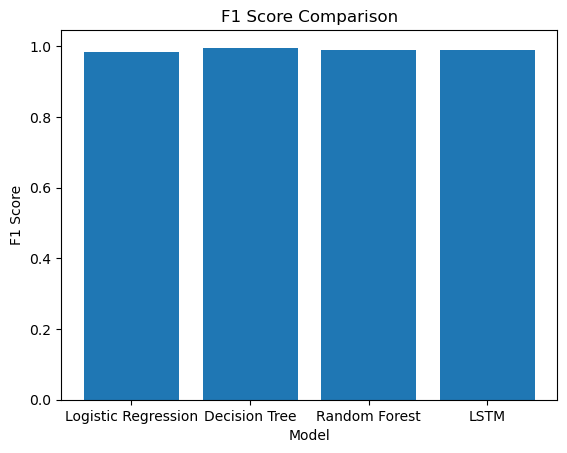

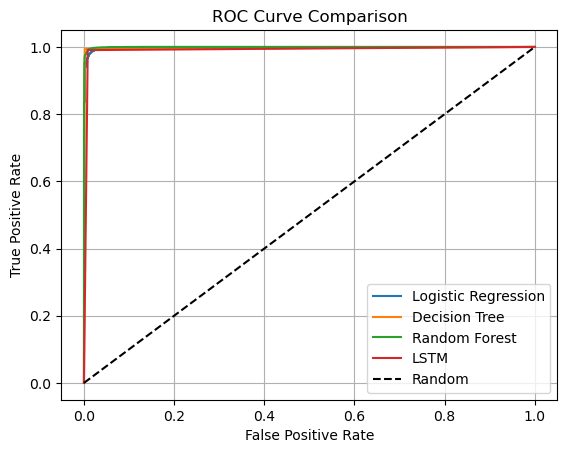

In [44]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Compute AUC and F1 scores
f1_scores = []
roc_aucs = []
model_names = df_metrics['Model'].tolist()

for name in model_names:
    if name == 'LSTM':
        probs = lstm_pred_probs
        preds = lstm_preds
    else:
        probs = models[name][0].predict_proba(X_test)[:, 1]
        preds = models[name][1]
    
    roc_aucs.append(roc_auc_score(y_test, probs))
    f1_scores.append(f1_score(y_test, preds))

# F1 Score Comparison
plt.figure()
plt.bar(model_names, f1_scores)
plt.title('F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.show()

# ROC Curve Plot
plt.figure()
for name in model_names:
    if name == 'LSTM':
        fpr, tpr, _ = roc_curve(y_test, lstm_pred_probs)
    else:
        probas = models[name][0].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probas)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()
